In [23]:
import os
import sys
import pandas as pd


sys.path.append(os.path.abspath(".."))

from utils.config import Configuration, load_config

config = load_config("../config.yaml")

tsv_dir = os.path.join("..", config.nsd_data.nsddata_responses_tsv_dir)

In [24]:
import h5py as h5
import numpy as np

subject = 1


sessions = [1, 10, 20, 30, 40]

freesurfer_dir = config.nsd_data.freesurfer_dir
v1_rois_lh = os.path.join(freesurfer_dir, f"subj{subject:02d}", "label", "customrois", f"lh.subj{subject:02d}.testrois.mgz")
v1_rois_rh = os.path.join(freesurfer_dir, f"subj{subject:02d}", "label", "customrois", f"rh.subj{subject:02d}.testrois.mgz")

t_test_rois_lh = "../data/t_test_roi/subj_01/lh.subj01.cleanedrois_3_0.mgz"
t_test_rois_rh = "../data/t_test_roi/subj_01/rh.subj01.cleanedrois_3_0.mgz"


import nibabel as nib

# Load MGZ files
lh_img = nib.load(v1_rois_lh)
rh_img = nib.load(v1_rois_rh)

# Get the data arrays
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()



# 'V1v': 1, 'V1d': 2
v1_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))


# Load MGZ files
lh_img = nib.load(t_test_rois_lh)
rh_img = nib.load(t_test_rois_rh)
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()
t_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))

v1_indices = np.where((v1_rois == 1) | (v1_rois == 2))[0]
t_indices = np.where(t_rois != 0)[0]

session=1


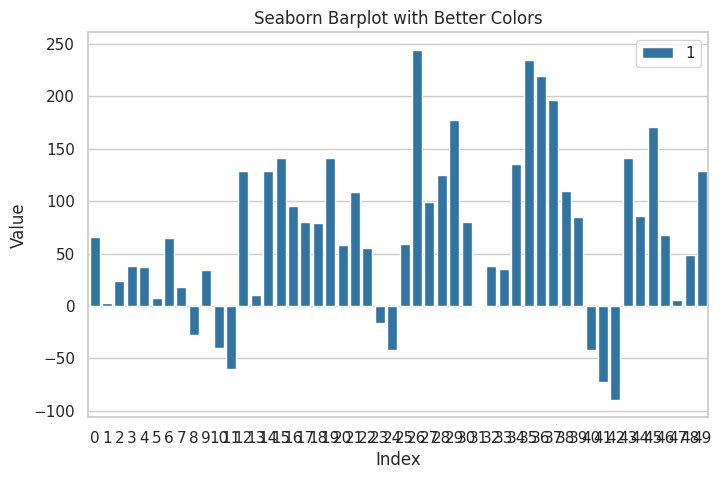

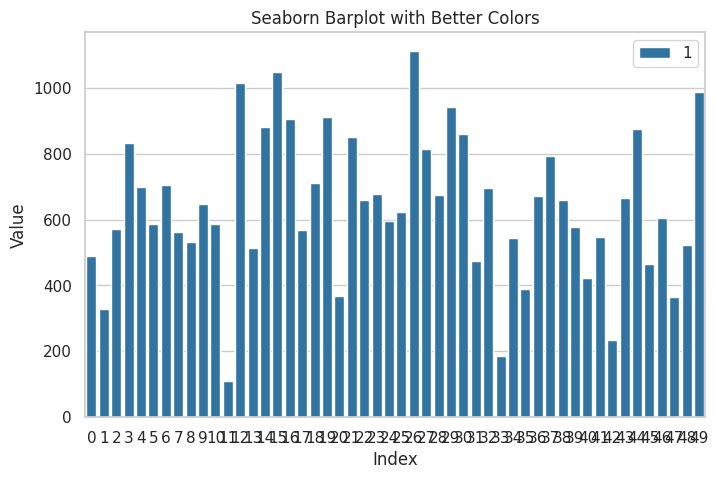

RUN
1     219.377700
2     192.558578
3     292.209203
4     251.331079
5     227.181118
6     355.105538
7     238.441573
8     245.498766
9     240.899247
10    250.158593
11    245.465605
12    226.633639
Name: MEAN_BETA, dtype: float64
RUN
1     669.526092
2     683.125353
3     669.461043
4     822.797443
5     743.315345
6     606.719671
7     825.398016
8     669.981977
9     779.057738
10    638.568946
11    745.140203
12    815.626365
Name: MEAN_BETA, dtype: float64
722.5232350065801


In [25]:
import os
import h5py as h5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

subject = 1  # Adjust if needed


tsv_path = os.path.join(
        tsv_dir,
        "ppdata",
        f"subj{subject:02d}",
        "behav",
        "responses.tsv",
    )

    # having all of the array loaded at once results in memory pressure
    # reduce to needed subset!

tsv_data = pd.read_csv(tsv_path, sep="\t")

data = []


for session in [1]:
    print(f"{session=}")
    # Define subject and session
    #session = 1  # Analyzing session 1
    betas_dir = f"/path_to_nsddata/ppdata/subj{subject:02d}/nativesurface/betas_fithrf_GLMdenoise_RR"

    # Load beta values from HDF5 files
    beta_lh_path = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
    beta_rh_path = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")

    def load_betas(session):
        betas_dir = os.path.join(config.nsd_data.nsddata_betas_dir, "ppdata", f"subj{subject:02d}", "nativesurface", "betas_fithrf_GLMdenoise_RR")
        beta_lh = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
        beta_rh = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")



        with h5.File(beta_lh, 'r') as f:
            betas_lh = f['betas'][:]  # Shape: [n_samples, n_voxels]


        with h5.File(beta_rh, 'r') as f:
            betas_rh = f['betas'][:]  # Shape: [n_samples, n_voxels]

        betas_concat = np.concatenate((betas_lh, betas_rh), axis=1)

        return betas_concat

    betas = load_betas(session)
    betas_v1 = betas[:, v1_indices]

    n_sample_plots = 50

    # Filter only session 1
    df_session1 = tsv_data[tsv_data['SESSION'] == session].copy()

    classes = np.array(df_session1["RUN"].tolist())[:n_sample_plots]
    
    palette = sns.color_palette("tab10", len(np.unique(classes)))

    # Combine hemispheres (optional: take mean across hemispheres)
    mean_betas_v1 = np.mean(betas_v1, axis=1)
    mean_betas = np.mean(betas, axis=1)

    

    if True:
        y_values = np.array(mean_betas[:n_sample_plots])

        # Generate x labels (indices)
        x_labels = np.arange(len(y_values))

        # Set a better style
        sns.set_style("whitegrid")  # You can also try "darkgrid" or "ticks"

        # Create barplot
        plt.figure(figsize=(8, 5))
        sns.barplot(x=x_labels, y=y_values, palette=palette, hue=classes)  # Try "Blues", "magma", "coolwarm"

        # Add labels
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.title("Seaborn Barplot with Better Colors")

        plt.show()


        y_values = np.array(mean_betas_v1[:n_sample_plots])

        # Generate x labels (indices)
        x_labels = np.arange(len(y_values))

        # Set a better style
        sns.set_style("whitegrid")  # You can also try "darkgrid" or "ticks"

        # Create barplot
        plt.figure(figsize=(8, 5))
        sns.barplot(x=x_labels, y=y_values, palette=palette, hue=classes)  # Try "Blues", "magma", "coolwarm"

        # Add labels
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.title("Seaborn Barplot with Better Colors")

        plt.show()
    

    # Ensure trials in dataframe align with betas (assuming NSD order is maintained)
    df_session1['MEAN_BETA'] = mean_betas_v1[:len(df_session1)]  # Assign mean beta values to corresponding trials

    # Compute mean response amplitude per run
    mean_response_per_run = df_session1.groupby('RUN')['MEAN_BETA'].mean()
    print(df_session1.groupby('RUN')['MEAN_BETA'].std())
    
    
    mean_response_per_session = df_session1.groupby('SESSION')['MEAN_BETA'].mean().iloc[0]
    data.append(mean_response_per_session)

    print(mean_response_per_run)
    print(mean_response_per_session)


In [26]:
for i in range(len(mean_betas)):
    print(mean_betas_v1[i])
    if i == 50:break
    if mean_betas_v1[i] < 50:
        print(i)

488.08516638465875
329.3570219966159
569.7948392554991
833.2405527354766
698.8629441624365
585.9299210377891
704.3773265651438
562.5258037225042
532.295826283136
646.9798364354202
584.9658770445573
110.55908065425832
1013.9427523970671
514.8808516638466
879.3613931190073
1047.9677100958827
906.168358714044
569.2677664974619
711.6304286520023
911.4135645798083
368.90947546531305
850.658065425832
658.38508178229
676.2918781725888
595.429780033841
621.3936830231246
1112.7416807670616
813.6175972927242
674.7944162436548
941.047236322617
860.1551043429216
474.98871968415114
696.5276367738296
187.38719684151155
544.1941624365483
389.4371122391427
670.9349971799211
793.8320642978003
660.4858996051889
576.5489283699943
422.6826001128032
546.7241962774958
235.9505076142132
666.5279187817259
873.7994923857868
465.6022278623801
603.6381838691483
366.4106034968979
521.7048787366047
985.988437676255
588.091934574168


In [27]:
import os
import h5py as h5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

subject = 1  # Adjust if needed


tsv_path = os.path.join(
        tsv_dir,
        "ppdata",
        f"subj{subject:02d}",
        "behav",
        "responses.tsv",
    )

    # having all of the array loaded at once results in memory pressure
    # reduce to needed subset!

tsv_data = pd.read_csv(tsv_path, sep="\t")

data = []


for session in [1]:
    print(f"{session=}")
    # Define subject and session
    #session = 1  # Analyzing session 1
    betas_dir = f"/path_to_nsddata/ppdata/subj{subject:02d}/nativesurface/betas_fithrf_GLMdenoise_RR"

    # Load beta values from HDF5 files
    beta_lh_path = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
    beta_rh_path = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")

    def load_betas(session):
        betas_dir = os.path.join(config.nsd_data.nsddata_betas_dir, "ppdata", f"subj{subject:02d}", "nativesurface", "betas_fithrf_GLMdenoise_RR")
        beta_lh = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
        beta_rh = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")



        with h5.File(beta_lh, 'r') as f:
            betas_lh = f['betas'][:]  # Shape: [n_samples, n_voxels]


        with h5.File(beta_rh, 'r') as f:
            betas_rh = f['betas'][:]  # Shape: [n_samples, n_voxels]

        betas_concat = np.concatenate((betas_lh, betas_rh), axis=1)

        return betas_concat

    betas = load_betas(session)
    betas_v1 = betas[:, v1_indices]


    


session=1


In [28]:
percentile =60

# normalized_samples = np.array([(sample - np.mean(sample)) / np.std(sample) for sample in betas])

normalized_samples = np.array([(sample) / np.std(sample) for sample in betas])

# 2. Globale Skalierung anhand des 75. Perzentils pro Sample
# global_amplitudes = np.array([np.percentile(np.abs(sample), percentile) for sample in betas_v1])

global_amplitudes = np.array([np.mean(np.abs(sample)) for sample in betas_v1])
global_amplitude_mean = np.mean(global_amplitudes)

print(global_amplitudes)
print(global_amplitude_mean)

[ 562.71150592  449.83164129  628.20093063  880.84884377  754.9749013
  653.73364354  748.09531867  637.58305133  621.43598421  728.54751833
  713.66328257  575.07318105 1039.9323181   571.09715172  940.2108009
 1078.40200226  963.63451777  638.04187817  745.25930626  950.9214608
  459.73632262  916.16398759  717.07656514  725.35476593  648.82797518
  697.17653694 1136.82910321  858.81133672  708.37055838  960.41384659
  886.17258883  579.67963903  760.73124647  376.25690919  644.33770446
  484.52679075  744.29145516  870.08333333  702.27721376  621.91187253
  562.02552171  674.07980823  499.90031021  707.63959391  906.50310209
  548.1287366   687.72109419  459.30315849  603.52918782 1004.95657078
  642.08291032  683.24873096  867.73998872  715.69966159  850.80851664
  882.6749859   721.35631698  840.9214608  1002.76861252  732.80428652
 1178.47913142 1014.00874224  660.68443316  599.00324309  633.35532995
  745.15383531  924.00225606  968.15637338  945.63127468  820.97264523
  760.920

In [29]:
import numpy as np

percentile = 60

# 1. Lokale Z-Normalisierung effizient mit NumPy
means = np.mean(betas, axis=1, keepdims=True)  # Berechnet Mittelwerte für jede Zeile (Sample)
stds = np.std(betas, axis=1, keepdims=True)  # Berechnet Standardabweichungen für jede Zeile
normalized_samples = (betas - means) / stds  # Elementweise Berechnung

# 2. Globale Skalierung anhand des Perzentils
global_amplitudes = np.percentile(np.abs(betas_v1), percentile, axis=1)  # 60. Perzentil pro Zeile

# Falls du global_amplitudes für Skalierung nutzen willst, kannst du direkt
# eine weitere vektorisierte Berechnung darauf aufbauen:
# scaled_samples = normalized_samples * (global_amplitudes[:, np.newaxis] / global_amplitudes.mean())


In [30]:
normalized_samples.shape

(750, 453622)

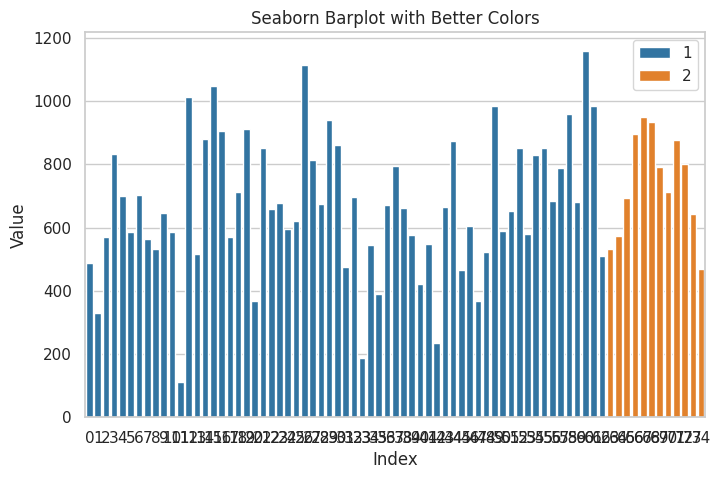

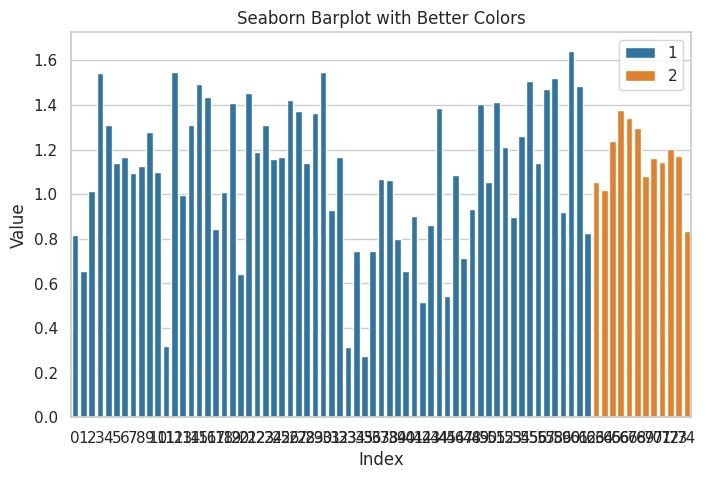

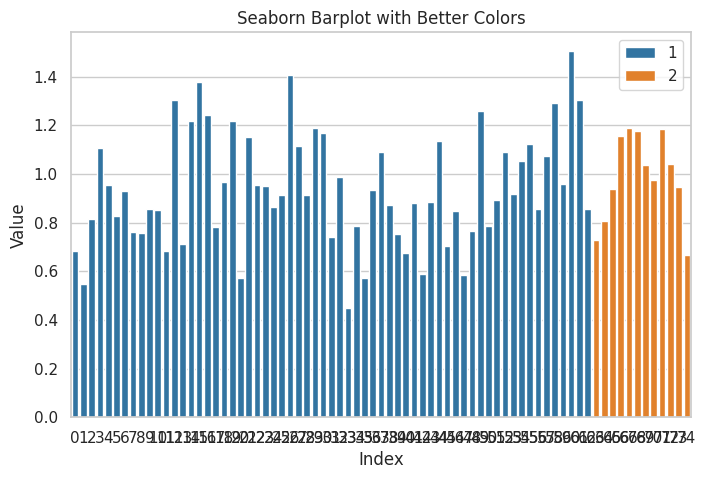

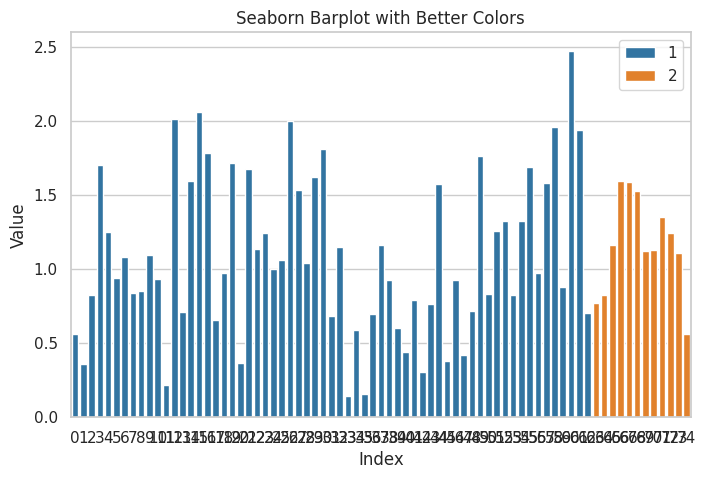

In [31]:
n_sample_plots = 75

# Filter only session 1
df_session1 = tsv_data[tsv_data['SESSION'] == session].copy()

classes = np.array(df_session1["RUN"].tolist())[:n_sample_plots]

palette = sns.color_palette("tab10", len(np.unique(classes)))

# Combine hemispheres (optional: take mean across hemispheres)
mean_betas_v1 = np.mean(betas_v1, axis=1)
mean_betas = np.mean(betas, axis=1)

mean_normalized_samples = np.mean(normalized_samples[:, v1_indices], axis=1)

scaling_factors = global_amplitudes / np.mean(global_amplitudes)


if True:
    for vals in [mean_betas_v1, mean_normalized_samples, scaling_factors, mean_normalized_samples*scaling_factors]:

        y_values = np.array(vals[:n_sample_plots])

        # Generate x labels (indices)
        x_labels = np.arange(len(y_values))

        # Set a better style
        sns.set_style("whitegrid")  # You can also try "darkgrid" or "ticks"

        # Create barplot
        plt.figure(figsize=(8, 5))
        sns.barplot(x=x_labels, y=y_values, palette=palette, hue=classes)  # Try "Blues", "magma", "coolwarm"

        # Add labels
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.title("Seaborn Barplot with Better Colors")

        plt.show()

In [32]:

def compute_scaling_matrix(array):
    """Compute the scaling factor matrix for a given array."""
    array = np.array(array)
    return array[:, None] / array[None, :]

def compare_matrices(M1, M2):
    """Compare two scaling matrices and compute deviation from 1."""
    diff1 = np.abs(M1 - 1)  # How far values in M1 are from 1
    diff2 = np.abs(M2 - 1)  # How far values in M2 are from 1

    # Compute total deviation for both matrices
    score1 = np.sum(diff1)
    score2 = np.sum(diff2)

    return score1, score2, "M1 is better" if score1 < score2 else "M2 is better"

# Example input array
array1 = mean_betas_v1
array2 = mean_normalized_samples
array3 = mean_normalized_samples * scaling_factors

# Compute scaling matrices
M1 = compute_scaling_matrix(array1)
M2 = compute_scaling_matrix(array2)
M3 = compute_scaling_matrix(array3)

# Compare matrices
score1, score2, better_fit = compare_matrices(M1, M2)

# Convert results to DataFrame for visualization
df_M1 = pd.DataFrame(M1, columns=array1, index=array1)
df_M2 = pd.DataFrame(M2, columns=array2, index=array2)

# Display results
print("Scaling Matrix 1:")
# print(df_M1)
print("\nScaling Matrix 2:")
# print(df_M2)
print(f"\nDeviation Scores: M1 = {score1}, M2 = {score2}")
print(f"Better Fit: {better_fit}")

score1, score2, better_fit = compare_matrices(M2, M3)
print(f"\nDeviation Scores: M1 = {score1}, M2 = {score2}")
print(f"Better Fit: {better_fit}")


Scaling Matrix 1:

Scaling Matrix 2:

Deviation Scores: M1 = 468026.4736889617, M2 = 363552.8085175601
Better Fit: M2 is better

Deviation Scores: M1 = 363552.8085175601, M2 = 771510.6908666337
Better Fit: M1 is better


In [33]:

def compute_scaling_matrix(array):
    """Compute the scaling factor matrix for a given array."""
    array = np.array(array)
    return array[:, None] / array[None, :]

def compare_matrices(M1, M2):
    """Compare two scaling matrices and compute deviation from 1."""
    diff1 = np.abs(M1 - 1)  # How far values in M1 are from 1
    diff2 = np.abs(M2 - 1)  # How far values in M2 are from 1

    # Compute total deviation for both matrices
    score1 = np.sum(diff1)
    score2 = np.sum(diff2)

    return score1, score2, "M1 is better" if score1 < score2 else "M2 is better"

# Example input array
array1 = np.array([1, 2, 4, 8])
array2 = np.array([1, 3, 6, 12])  # Second array to compare

# Compute scaling matrices
M1 = compute_scaling_matrix(array1)
M2 = compute_scaling_matrix(array2)

# Compare matrices
score1, score2, better_fit = compare_matrices(M1, M2)

# Convert results to DataFrame for visualization
df_M1 = pd.DataFrame(M1, columns=array1, index=array1)
df_M2 = pd.DataFrame(M2, columns=array2, index=array2)

# Display results
print("Scaling Matrix 1:")
print(df_M1)
print("\nScaling Matrix 2:")
print(df_M2)
print(f"\nDeviation Scores: M1 = {score1}, M2 = {score2}")
print(f"Better Fit: {better_fit}")

Scaling Matrix 1:
     1    2     4      8
1  1.0  0.5  0.25  0.125
2  2.0  1.0  0.50  0.250
4  4.0  2.0  1.00  0.500
8  8.0  4.0  2.00  1.000

Scaling Matrix 2:
      1         3         6         12
1    1.0  0.333333  0.166667  0.083333
3    3.0  1.000000  0.500000  0.250000
6    6.0  2.000000  1.000000  0.500000
12  12.0  4.000000  2.000000  1.000000

Deviation Scores: M1 = 19.875, M2 = 27.166666666666668
Better Fit: M1 is better


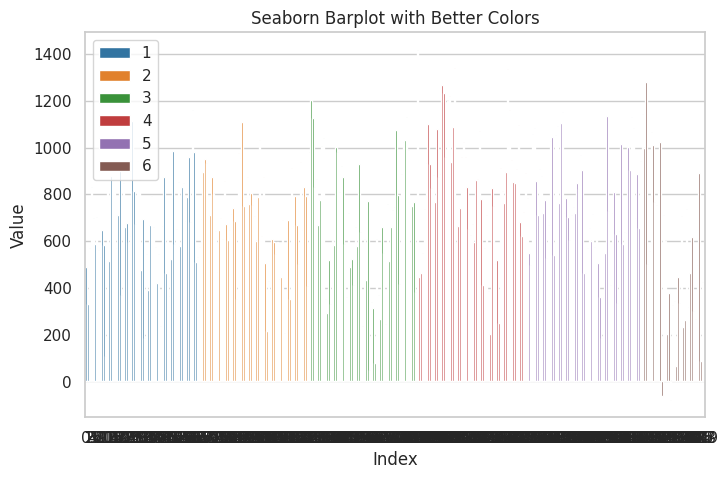

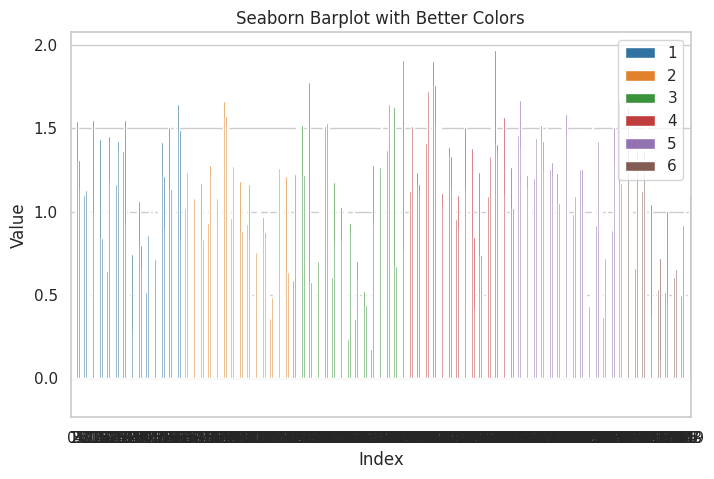

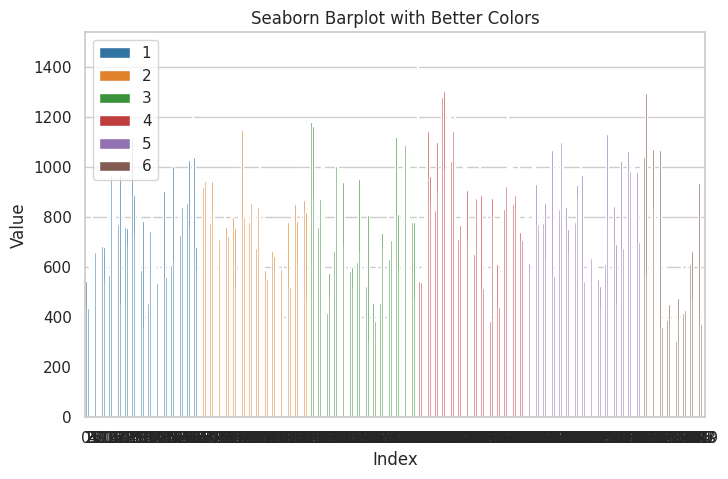

In [34]:
n_sample_plots = 350

# Filter only session 1
df_session1 = tsv_data[tsv_data['SESSION'] == session].copy()

classes = np.array(df_session1["RUN"].tolist())[:n_sample_plots]

palette = sns.color_palette("tab10", len(np.unique(classes)))

# Combine hemispheres (optional: take mean across hemispheres)
mean_betas_v1 = np.mean(betas_v1, axis=1)
mean_betas = np.mean(betas, axis=1)

mean_normalized_samples = np.mean(normalized_samples[:, v1_indices], axis=1)


if True:
    for vals in [mean_betas_v1, mean_normalized_samples, global_amplitudes]:

        y_values = np.array(vals[:n_sample_plots])

        # Generate x labels (indices)
        x_labels = np.arange(len(y_values))

        # Set a better style
        sns.set_style("whitegrid")  # You can also try "darkgrid" or "ticks"

        # Create barplot
        plt.figure(figsize=(8, 5))
        sns.barplot(x=x_labels, y=y_values, palette=palette, hue=classes)  # Try "Blues", "magma", "coolwarm"

        # Add labels
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.title("Seaborn Barplot with Better Colors")

        plt.show()

In [35]:
data

[]

In [36]:
subject_id = 1

tsv_path = os.path.join(
        tsv_dir,
        "ppdata",
        f"subj{subject_id:02d}",
        "behav",
        "responses.tsv",
    )

    # having all of the array loaded at once results in memory pressure
    # reduce to needed subset!

tsv_data = pd.read_csv(tsv_path, sep="\t")

In [37]:
    tsv_data

,SUBJECT,SESSION,RUN,TRIAL,73KID,10KID,TIME,ISOLD,ISCORRECT,RT,CHANGEMIND,MEMORYRECENT,MEMORYFIRST,ISOLDCURRENT,ISCORRECTCURRENT,TOTAL1,TOTAL2,BUTTON,MISSINGDATA
0,1,1,1,1,46003,626,0.505082,0,1.0,803.529781,0.0,NaN,NaN,0,1.0,1,0,1.0,0
1,1,1,1,2,61883,5013,0.505128,0,1.0,972.261383,0.0,NaN,NaN,0,1.0,1,0,1.0,0
2,1,1,1,3,829,4850,0.505175,0,1.0,742.351236,0.0,NaN,NaN,0,1.0,1,0,1.0,0
3,1,1,1,4,67574,8823,0.505221,0,1.0,747.518479,0.0,NaN,NaN,0,1.0,1,0,1.0,0
4,1,1,1,5,16021,9538,0.505267,0,1.0,547.422774,0.0,NaN,NaN,0,1.0,1,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,1,40,12,58,13774,8984,262.629551,1,0.0,1275.300175,0.0,20963.0,21540.0,0,1.0,1,0,1.0,0
29996,1,40,12,59,66768,6026,262.629597,1,1.0,661.379768,0.0,16.0,17622.0,1,1.0,0,1,2.0,0
29997,1,40,12,60,53168,4841,262.629644,1,1.0,786.811781,0.0,9483.0,11912.0,0,0.0,0,1,2.0,0
29998,1,40,12,61,1944,7323,262.629690,1,1.0,502.626801,0.0,83.0,12162.0,1,1.0,0,1,2.0,0


In [38]:
from collections import Counter
import numpy as np
from collections import defaultdict



results = []

sample_dict = defaultdict(list)

for i in range(1, 40+1):
    result_dict_session = {}

    entries_session = tsv_data[tsv_data["SESSION"] == i]
    entry_ids = entries_session["73KID"].tolist()

    for entry_id in list(set(entry_ids)):
        entries_sample = entries_session[entries_session["73KID"] == entry_id]


        result_dict_session[entry_id] = {
            "count" : len(entries_sample) 
        }

        for row_i, row in entries_sample.iterrows():
            sample_dict[entry_id].append({
                "session" : int(row["SESSION"]),
                "index" : row_i,
                "session_index" : row_i - (int(row["SESSION"])-1)*750,
                "73KID" : entry_id
            }) 

            result_dict_session[entry_id]["session"] = int(row["SESSION"])
            result_dict_session[entry_id]["index"] = row_i
            result_dict_session[entry_id]["session_index"] = row_i - (int(row["SESSION"])-1)*750


    if i==1:
        print(result_dict_session)

    results.append(result_dict_session)


res_matrix = np.zeros((40, 40))
for i in range(40):
    entry_ids_i = list(results[i].keys())
    for j in range(40):
        if i==j:
            continue

        entry_ids_j = list(results[j].keys())

        overlap = list(set(entry_ids_i) & set(entry_ids_j))

        res_matrix[i,j] = len(overlap)
        res_matrix[j,i] = len(overlap)




{2050: {'count': 1, 'session': 1, 'index': 454, 'session_index': 454}, 38919: {'count': 1, 'session': 1, 'index': 215, 'session_index': 215}, 28681: {'count': 1, 'session': 1, 'index': 252, 'session_index': 252}, 38925: {'count': 3, 'session': 1, 'index': 493, 'session_index': 493}, 49171: {'count': 1, 'session': 1, 'index': 106, 'session_index': 106}, 28691: {'count': 3, 'session': 1, 'index': 517, 'session_index': 517}, 59411: {'count': 1, 'session': 1, 'index': 545, 'session_index': 545}, 47126: {'count': 2, 'session': 1, 'index': 664, 'session_index': 664}, 10263: {'count': 1, 'session': 1, 'index': 697, 'session_index': 697}, 38937: {'count': 2, 'session': 1, 'index': 719, 'session_index': 719}, 51228: {'count': 2, 'session': 1, 'index': 374, 'session_index': 374}, 18469: {'count': 1, 'session': 1, 'index': 51, 'session_index': 51}, 22565: {'count': 1, 'session': 1, 'index': 651, 'session_index': 651}, 28711: {'count': 2, 'session': 1, 'index': 658, 'session_index': 658}, 8236: {'

<Axes: >

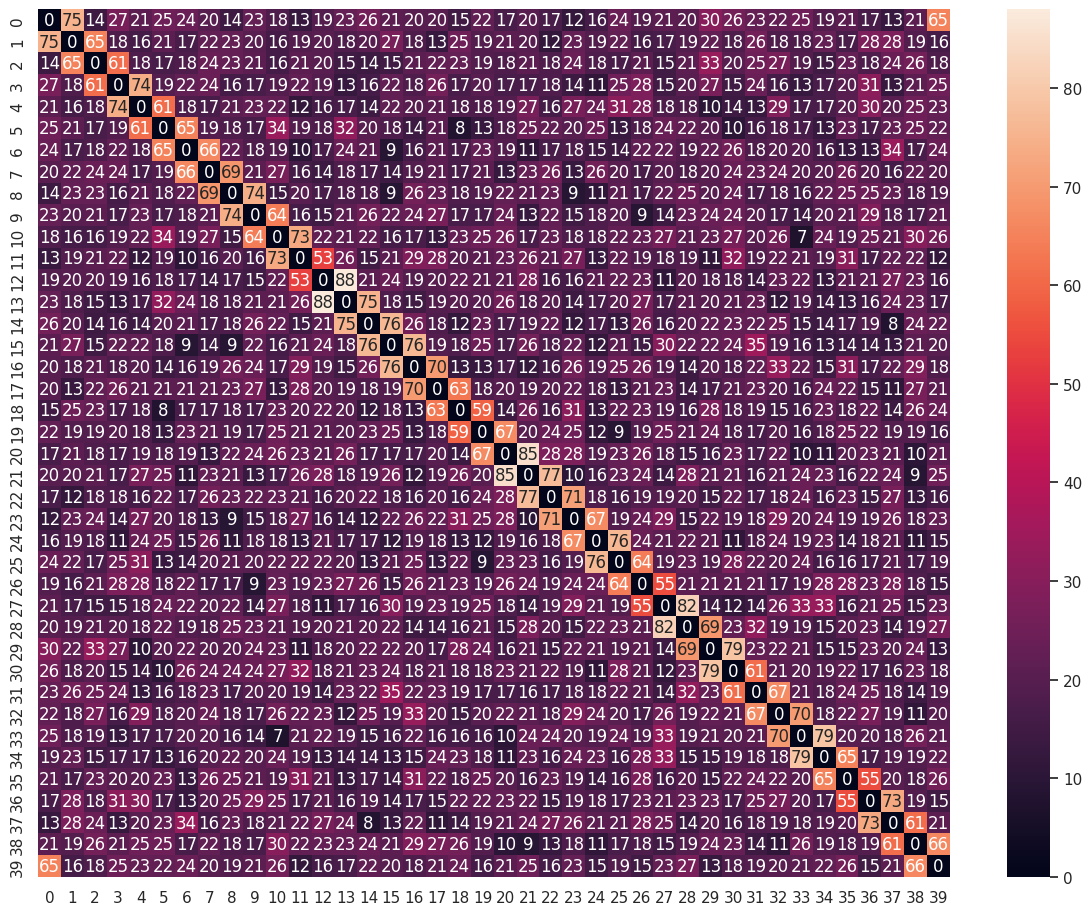

In [39]:
import seaborn as sns
sns.set_theme(rc={'figure.figsize':(14.7,11.27)})
sns.heatmap(res_matrix, annot=True)

In [40]:
dict(sample_dict)

{2050: [{'session': 1, 'index': 454, 'session_index': 454, '73KID': 2050},
  {'session': 35, 'index': 25903, 'session_index': 403, '73KID': 2050},
  {'session': 35, 'index': 26016, 'session_index': 516, '73KID': 2050}],
 38919: [{'session': 1, 'index': 215, 'session_index': 215, '73KID': 38919},
  {'session': 39, 'index': 28801, 'session_index': 301, '73KID': 38919},
  {'session': 40, 'index': 29994, 'session_index': 744, '73KID': 38919}],
 28681: [{'session': 1, 'index': 252, 'session_index': 252, '73KID': 28681},
  {'session': 40, 'index': 29772, 'session_index': 522, '73KID': 28681},
  {'session': 40, 'index': 29857, 'session_index': 607, '73KID': 28681}],
 38925: [{'session': 1, 'index': 103, 'session_index': 103, '73KID': 38925},
  {'session': 1, 'index': 213, 'session_index': 213, '73KID': 38925},
  {'session': 1, 'index': 493, 'session_index': 493, '73KID': 38925}],
 49171: [{'session': 1, 'index': 106, 'session_index': 106, '73KID': 49171},
  {'session': 4, 'index': 2272, 'sess

In [41]:
import h5py as h5

subject = 1


sessions = [1, 10, 20, 30, 40]

freesurfer_dir = config.nsd_data.freesurfer_dir
v1_rois_lh = os.path.join(freesurfer_dir, f"subj{subject:02d}", "label", "customrois", f"lh.subj{subject:02d}.testrois.mgz")
v1_rois_rh = os.path.join(freesurfer_dir, f"subj{subject:02d}", "label", "customrois", f"rh.subj{subject:02d}.testrois.mgz")



import nibabel as nib

# Load MGZ files
lh_img = nib.load(v1_rois_lh)
rh_img = nib.load(v1_rois_rh)

# Get the data arrays
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()

# 'V1v': 1, 'V1d': 2
v1_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))

v1_indices = np.where((v1_rois == 1) | (v1_rois == 2))[0]

In [42]:

loaded_betas = []

for session in sessions:
    betas_dir = os.path.join(config.nsd_data.nsddata_betas_dir, "ppdata", f"subj{subject:02d}", "nativesurface", "betas_fithrf_GLMdenoise_RR")
    beta_lh = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
    beta_rh = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")



    with h5.File(beta_lh, 'r') as f:
        betas_lh = f['betas'][:]  # Shape: [n_samples, n_voxels]


    with h5.File(beta_rh, 'r') as f:
        betas_rh = f['betas'][:]  # Shape: [n_samples, n_voxels]

    betas_concat = np.concatenate((betas_lh, betas_rh), axis=1)


    loaded_betas.append(betas_concat)


In [43]:
for i in range(len(sessions)):
    print(f"session: {sessions[i]} - {np.mean(loaded_betas[i])}")
    print(f"session: {sessions[i]} - {np.mean(loaded_betas[i][:, v1_indices])}")




session: 1 - 90.91367337856923
session: 1 - 722.5232350065802
session: 10 - 63.466428215562736
session: 10 - 795.2457883060725
session: 20 - 67.14836034113571
session: 20 - 788.545204925738
session: 30 - 68.9272679484975
session: 30 - 689.7942045497274
session: 40 - 64.91988536711183
session: 40 - 743.063870464373


Looping id_loop=18171
[{'session': 9, 'index': 6435, 'session_index': 435, '73KID': 18171}, {'session': 23, 'index': 17207, 'session_index': 707, '73KID': 18171}, {'session': 23, 'index': 17249, 'session_index': 749, '73KID': 18171}]
[9, 23]
Taking sample 435 from session=9 np.mean(betas_concat[sample['session_index']])=np.float64(190.6165220892354)
Taking sample 707 from session=23 np.mean(betas_concat[sample['session_index']])=np.float64(93.43435452582263)
Taking sample 749 from session=23 np.mean(betas_concat[sample['session_index']])=np.float64(163.26503422275906)


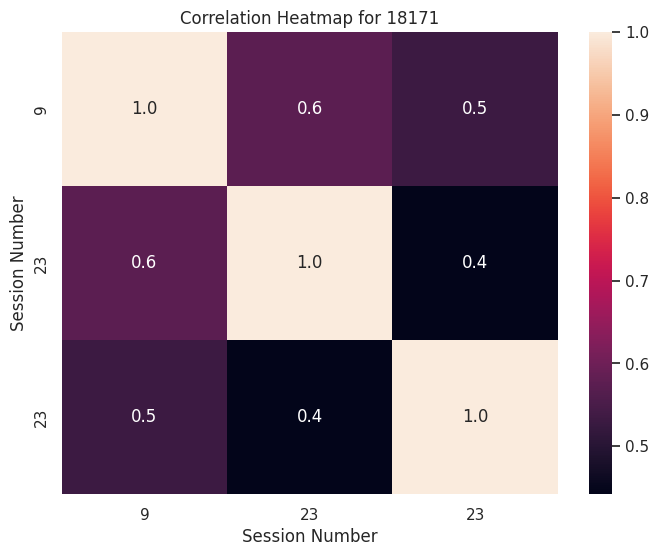

In [44]:
# 18040: 2
from IPython.display import Image, display
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns


# ids_to_loop = [46003, 18040]
# ids_to_loop = list(sample_dict.keys())[:5]
#ids_to_loop = [18170+1, 34200+1, 16649+1, 17623+1, 45528+1]
ids_to_loop = [18170+1]
plots = []

betas_results = []

t_test_rois_lh = "../data/t_test_roi/subj_01/lh.subj01.cleanedrois_3_0.mgz"
t_test_rois_rh = "../data/t_test_roi/subj_01/rh.subj01.cleanedrois_3_0.mgz"



# Load MGZ files
lh_img = nib.load(t_test_rois_lh)
rh_img = nib.load(t_test_rois_rh)
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()
t_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))

t_indices = np.where(t_rois != 0)[0]


for id_loop in ids_to_loop:
    betas = []
    print(f"Looping {id_loop=}")
    print(sample_dict[id_loop])

    print(list(set([e["session"] for e in sample_dict[id_loop]])))

    session_numbers = [e["session"] for e in sample_dict[id_loop]]
    for session in list(set([e["session"] for e in sample_dict[id_loop]])):
        betas_dir = os.path.join(config.nsd_data.nsddata_betas_dir, "ppdata", f"subj{subject:02d}", "nativesurface", "betas_fithrf_GLMdenoise_RR")
        beta_lh = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
        beta_rh = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")


        with h5.File(beta_lh, 'r') as f:
            betas_lh = f['betas'][:]  # Shape: [n_samples, n_voxels]


        with h5.File(beta_rh, 'r') as f:
            betas_rh = f['betas'][:]  # Shape: [n_samples, n_voxels]

        betas_concat = np.concatenate((betas_lh, betas_rh), axis=1)[:, t_indices]

        for sample in sample_dict[id_loop]:
            if sample["session"] == session:
                print(f"Taking sample {sample['session_index']} from {session=} {np.mean(betas_concat[sample['session_index']])=}")
                betas.append(betas_concat[sample["session_index"]])

    
    corrs = np.zeros((len(betas), len(betas)))
    for i in range(len(betas)):
        for j in range(len(betas)):
            corr = scipy.stats.pearsonr(betas[i], betas[j])
            corrs[i, j] = corr.statistic

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        corrs, 
        annot=True, 
        fmt=".1f", 
        cbar=True, 
        xticklabels=session_numbers,  # Set x-axis labels
        yticklabels=session_numbers   # Set y-axis labels

    )
    plt.xlabel("Session Number")
    plt.ylabel("Session Number")
    plt.title(f"Correlation Heatmap for {id_loop}")

    # Store the figure instead of the seaborn object
    plots.append(plt.gcf())  
    plt.close()  # Close the figure to prevent overlapping in Jupyter Notebook


    betas_results.append(np.vstack(betas))

# Display all figures
for plot in plots:
    display(plot)


In [45]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import h5py as h5
import os
import nibabel as nib

ids_to_loop = [18170+1]
ids_to_loop = [18170+1, 34200+1, 16649+1, 17623+1, 45528+1]

#ids_to_loop = [
#    18170, 34200, 16649, 28170, 58157, 57811, 46323, 2125, 18960, 67148, 
#    1136, 17623, 41853, 12258, 65222, 45528, 3920, 15516, 39302, 46807, 
#    25070, 60749, 59180, 60514, 63255, 67671, 14270, 15567, 17651, 19471, 
#    40325, 41126, 58839, 14631, 21193
#]


ids_to_loop = [e + 1 for e in ids_to_loop]


correlations = []

plots = []
betas_results = []

t_test_rois_lh = "../data/t_test_roi/subj_01/lh.subj01.cleanedrois_3_0.mgz"
t_test_rois_rh = "../data/t_test_roi/subj_01/rh.subj01.cleanedrois_3_0.mgz"

# Load MGZ files
lh_img = nib.load(t_test_rois_lh)
rh_img = nib.load(t_test_rois_rh)
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()
t_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))

t_indices = np.where(t_rois != 0)[0]  # Indizes der nicht-Null ROIs
unique_rois = np.unique(t_rois[t_rois > 0])  # ROIs von 1 bis 8

for id_loop in ids_to_loop:
    betas = []
    print(f"Looping {id_loop=}")

    session_numbers = [e["session"] for e in sample_dict[id_loop]]
    
    for session in list(set(session_numbers)):
        betas_dir = os.path.join(config.nsd_data.nsddata_betas_dir, "ppdata", f"subj{subject:02d}", "nativesurface", "betas_fithrf_GLMdenoise_RR")
        beta_lh = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
        beta_rh = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")

        with h5.File(beta_lh, 'r') as f:
            betas_lh = f['betas'][:]

        with h5.File(beta_rh, 'r') as f:
            betas_rh = f['betas'][:]

        betas_concat = np.concatenate((betas_lh, betas_rh), axis=1)[:, t_indices]

        for sample in sample_dict[id_loop]:
            if sample["session"] == session:
                betas.append(betas_concat[sample["session_index"]])

    betas = np.vstack(betas)  # Alle gesammelten Betas in eine Matrix

    # Korrelationen je ROI berechnen
    num_rois = len(unique_rois)

    # Figure und Subplots erstellen (1 Reihe, num_rois Spalten)
    fig, axes = plt.subplots(1, num_rois, figsize=(4 * num_rois, 4), sharex=True, sharey=True)

    for idx, roi in enumerate(unique_rois):
        roi_indices = np.where(t_rois[t_indices] == roi)[0]  # Indizes für diesen ROI
        
        if len(roi_indices) == 0:
            continue  # Falls kein Voxel für den ROI existiert, überspringen

        betas_roi = betas[:, roi_indices]  # Beta-Werte nur für diesen ROI

        # Korrelationen berechnen
        corrs = np.zeros((betas_roi.shape[0], betas_roi.shape[0]))
        for i in range(betas_roi.shape[0]):
            for j in range(betas_roi.shape[0]):
                corr = scipy.stats.pearsonr(betas_roi[i], betas_roi[j])
                corrs[i, j] = corr.statistic

        correlations.append(corrs)

        # Aktuelle Achse auswählen
        ax = axes[idx] if num_rois > 1 else axes  # Falls nur ein ROI existiert

        sns.heatmap(
            corrs,
            annot=True,
            fmt=".1f",
            cbar=True,
            xticklabels=session_numbers,
            yticklabels=session_numbers,
            ax=ax
        )
        ax.set_title(f"ROI {int(roi)}")

    # Gemeinsame Achsentitel setzen
    fig.supxlabel("Session Number")
    fig.supylabel("Session Number")
    fig.suptitle(f"Correlation Heatmaps for ROIs (ID {id_loop})", fontsize=14)

    # Zeigen der Heatmaps
    plt.tight_layout()
    plt.show()

# Alle Heatmaps anzeigen
for plot in plots:
    display(plot)


Looping id_loop=18172


ValueError: need at least one array to concatenate

In [49]:
t_test_rois_lh = "../data/t_test_roi/subj_01/lh.subj01.cleanedrois_3_0.mgz"
t_test_rois_rh = "../data/t_test_roi/subj_01/rh.subj01.cleanedrois_3_0.mgz"

# Load MGZ files
lh_img = nib.load(t_test_rois_lh)
rh_img = nib.load(t_test_rois_rh)
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()
t_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))

t_indices = np.where(t_rois != 0)[0]  # Indizes der nicht-Null ROIs
unique_rois = np.unique(t_rois[t_rois > 0])  # ROIs von 1 bis 8

# Korrelationen je ROI berechnen
num_rois = len(unique_rois)

for idx, roi in enumerate(unique_rois):
    roi_indices = np.where(t_rois[t_indices] == roi)[0]  # Indizes für diesen ROI

In [46]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import h5py as h5
import os
import nibabel as nib

ids_to_loop = [18170+1]
ids_to_loop = [18170+1, 34200+1, 16649+1, 17623+1, 45528+1]

ids_to_loop = [
13, 18170, 16649

]


ids_to_loop = [e + 1 for e in ids_to_loop]


correlations = []

plots = []
betas_results = []

t_test_rois_lh = "../data/t_test_roi/subj_01/lh.subj01.cleanedrois_3_0.mgz"
t_test_rois_rh = "../data/t_test_roi/subj_01/rh.subj01.cleanedrois_3_0.mgz"

# Load MGZ files
lh_img = nib.load(t_test_rois_lh)
rh_img = nib.load(t_test_rois_rh)
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()
t_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))

t_indices = np.where(t_rois != 0)[0]  # Indizes der nicht-Null ROIs
unique_rois = np.unique(t_rois[t_rois > 0])  # ROIs von 1 bis 8


betas = []

for id_loop in ids_to_loop:
    print(f"Looping {id_loop=}")

    session_numbers = [e["session"] for e in sample_dict[id_loop]]
    
    for session in list(set(session_numbers)):
        betas_dir = os.path.join(config.nsd_data.nsddata_betas_dir, "ppdata", f"subj{subject:02d}", "nativesurface", "betas_fithrf_GLMdenoise_RR")
        beta_lh = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
        beta_rh = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")

        with h5.File(beta_lh, 'r') as f:
            betas_lh = f['betas'][:]

        with h5.File(beta_rh, 'r') as f:
            betas_rh = f['betas'][:]

        betas_concat = np.concatenate((betas_lh, betas_rh), axis=1)[:, t_indices]

        for sample in sample_dict[id_loop]:
            if sample["session"] == session:
                betas.append(betas_concat[sample["session_index"]])

    #betas = np.vstack(betas)  # Alle gesammelten Betas in eine Matrix

    # Korrelationen je ROI berechnen
    """num_rois = len(unique_rois)

    # Figure und Subplots erstellen (1 Reihe, num_rois Spalten)
    fig, axes = plt.subplots(1, num_rois, figsize=(4 * num_rois, 4), sharex=True, sharey=True)

    for idx, roi in enumerate(unique_rois):
        roi_indices = np.where(t_rois[t_indices] == roi)[0]  # Indizes für diesen ROI
        
        if len(roi_indices) == 0:
            continue  # Falls kein Voxel für den ROI existiert, überspringen

        betas_roi = betas[:, roi_indices]  # Beta-Werte nur für diesen ROI

        # Korrelationen berechnen
        corrs = np.zeros((betas_roi.shape[0], betas_roi.shape[0]))
        for i in range(betas_roi.shape[0]):
            for j in range(betas_roi.shape[0]):
                corr = scipy.stats.pearsonr(betas_roi[i], betas_roi[j])
                corrs[i, j] = corr.statistic

        correlations.append(corrs)

        # Aktuelle Achse auswählen
        ax = axes[idx] if num_rois > 1 else axes  # Falls nur ein ROI existiert

        sns.heatmap(
            corrs,
            annot=True,
            fmt=".1f",
            cbar=True,
            xticklabels=session_numbers,
            yticklabels=session_numbers,
            ax=ax
        )
        ax.set_title(f"ROI {int(roi)}")

    # Gemeinsame Achsentitel setzen
    fig.supxlabel("Session Number")
    fig.supylabel("Session Number")
    fig.suptitle(f"Correlation Heatmaps for ROIs (ID {id_loop})", fontsize=14)

    # Zeigen der Heatmaps
    plt.tight_layout()
    plt.show()"""

betas = np.array(betas)


Looping id_loop=14
Looping id_loop=18171
Looping id_loop=16650


In [47]:
correlations_stacked = np.array(correlations)
reshaped_corrs = np.array(correlations).reshape(280//8, 8, 3, 3)


n_samples = 280 // 8
# Leere Liste für die Mittelwerte
means_below_diagonal = np.zeros((n_samples, 8))

# Berechnung für jedes Sample & jedes ROI
for sample_idx in range(n_samples):
    for roi_idx in range(8):
        matrix = reshaped_corrs[sample_idx, roi_idx]  # 3x3 Matrix extrahieren
        lower_triangle_values = matrix[np.tril_indices(3, k=-1)]  # Werte unter der Diagonalen
        means_below_diagonal[sample_idx, roi_idx] = np.mean(lower_triangle_values)  # Mittelwert berechnen

ValueError: cannot reshape array of size 0 into shape (35,8,3,3)

In [ ]:
means_below_diagonal

array([[ 0.62734833,  0.14580005, -0.0945804 ,  0.19652123,  0.09302025,
         0.57404283,  0.40925151,  0.07269665],
       [ 0.37821746, -0.01180816, -0.0864476 , -0.10482449,  0.0585241 ,
         0.45672335,  0.47904578, -0.09294467],
       [ 0.30840958,  0.13642881,  0.15470886,  0.09751595,  0.16932789,
         0.48941413,  0.59393166,  0.24607071],
       [ 0.55088688,  0.25784355,  0.22665082,  0.25078794,  0.00101098,
         0.6534257 ,  0.50331138,  0.01183063],
       [ 0.48339275,  0.10886273, -0.07097877,  0.21810511,  0.15319071,
         0.65644889,  0.46789371, -0.03345794],
       [ 0.37588261,  0.18961451, -0.17821544,  0.07374135,  0.15537086,
         0.56457638,  0.37663655, -0.03034642],
       [ 0.60843306,  0.22217181,  0.12895334,  0.19395875,  0.08835008,
         0.74028843,  0.59227716,  0.2992368 ],
       [ 0.62093479,  0.23839883,  0.13394732,  0.1953935 ,  0.10507192,
         0.78033285,  0.56273859,  0.40587539],
       [ 0.54279406,  0.13289449

In [ ]:
mean_per_roi = np.mean(means_below_diagonal, axis=0)  # Ergebnis: (8,)
print("Mean over Samples per ROI:", mean_per_roi)
mean_per_sample = np.mean(means_below_diagonal, axis=1)  # Ergebnis: (n_samples,)
print("Mean over ROIs per Sample:", mean_per_sample)


Mean over Samples per ROI: [0.53570176 0.21888558 0.12583268 0.21405703 0.12726014 0.56510508
 0.51257393 0.18435199]
Mean over ROIs per Sample: [0.25301256 0.13456072 0.27447595 0.30696849 0.24793215 0.19090755
 0.35920868 0.38033665 0.28911755 0.36407092 0.5129658  0.36143938
 0.33739274 0.26232457 0.26827992 0.46208563 0.21869361 0.25764379
 0.30077717 0.41022596 0.13650958 0.4038405  0.14623595 0.33750488
 0.26563877 0.31647172 0.20223733 0.27352458 0.3750948  0.25051958
 0.37688506 0.47096057 0.37008114 0.43814164 0.31041996]


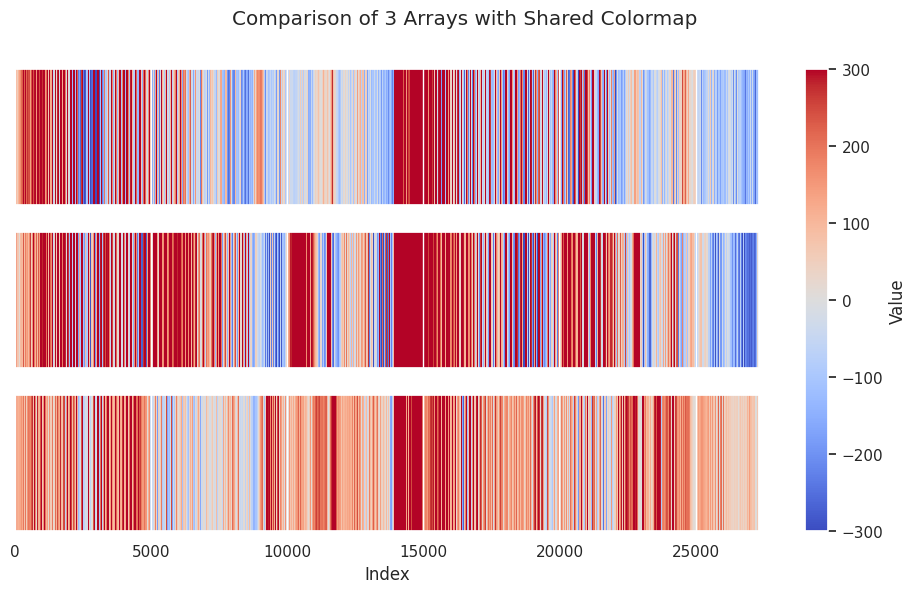

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True, sharey=True)



# Plot each array as a separate heatmap
for i, ax in enumerate(axes):
    for roi in range(1, 8+1):
        roi_indices_set = np.where(t_rois[t_indices] == roi)[0]  # Indizes für diesen ROI
        
        if len(roi_indices_set) == 0:
            continue  # Falls kein Voxel für den ROI existiert, überspringen

        betas_roi = betas[i, roi_indices_set]  # Beta-Werte nur für diesen ROI
        im = ax.imshow(betas[i].reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-300, vmax=300)
        ax.set_yticks([])  # Remove y-ticks
    #ax.set_ylabel(f"Array {i+1}")  # Label each row

# Colorbar (one for all plots)
fig.colorbar(im, ax=axes, orientation="vertical", label="Value")

plt.xlabel("Index")
plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
plt.show()

In [51]:
roi_sizes = []
roi_indices = []

for roi in range(1, 9):
    roi_indices_set = np.where(t_rois[t_indices] == roi)[0]
    roi_indices.append(roi_indices_set)
    roi_sizes.append(len(roi_indices_set))

print(roi_indices[-1])
print(t_indices)
print(t_rois)
print(t_rois.shape)

[ 9214  9215  9216 ... 25080 25081 25082]
[  8238   8239   9050 ... 452346 452355 452366]
[0. 0. 0. ... 0. 0. 0.]
(453622,)


In [ ]:
betas.shape




array([-33,   0, -85, ..., 628, 575, 517], dtype=int16)

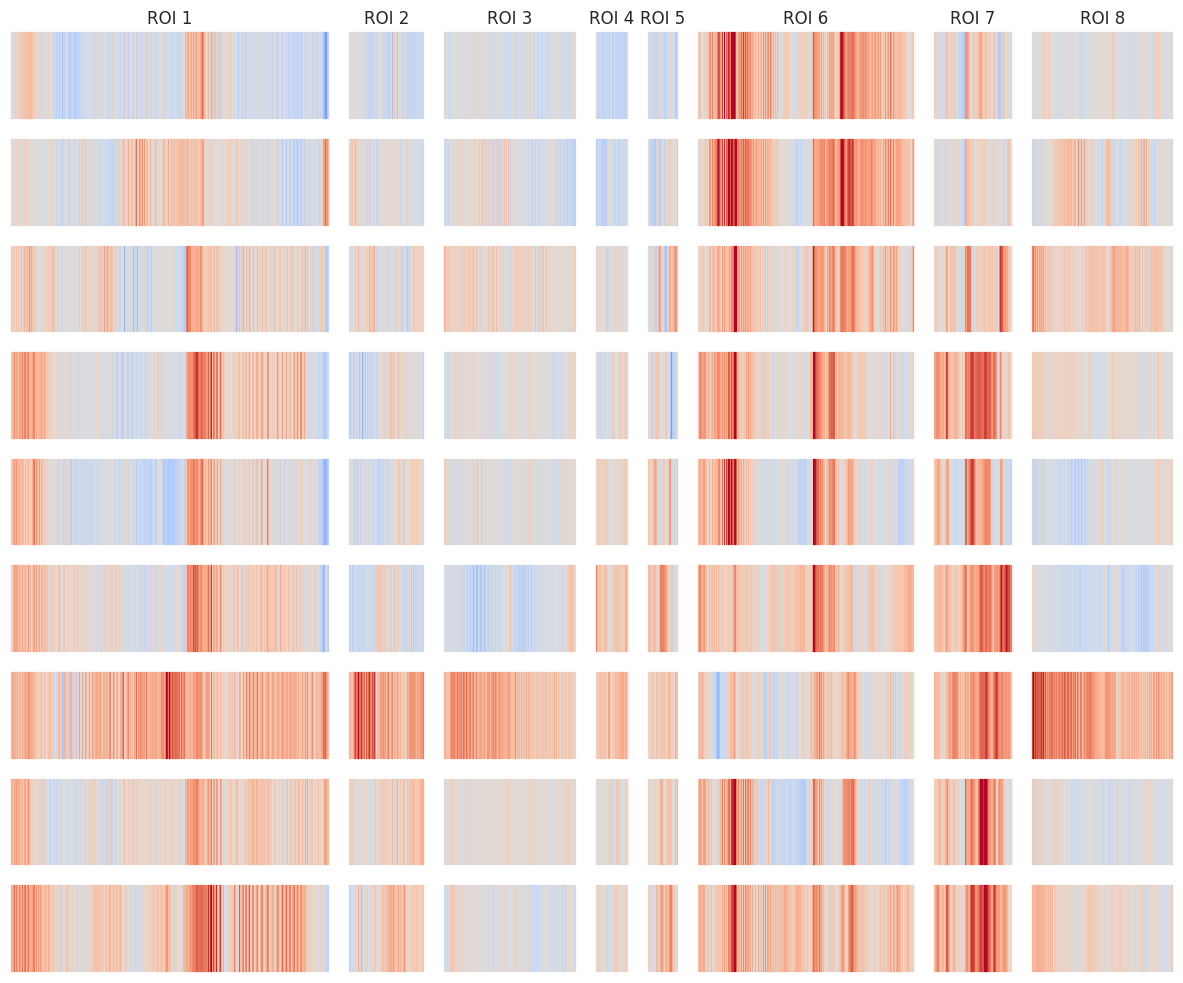

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
import scipy.spatial.distance as dist 

# Beispielhafte Daten: 3 Arrays mit zufälliger Anzahl an Voxel pro ROI
num_rois = 8

n_samples = 9

# Berechne die relative Breite jeder Spalte basierend auf der Anzahl der Voxel
col_widths = [size / sum(roi_sizes) for size in roi_sizes]  # Normierte Breiten für `gridspec`

# Erstelle das Grid mit dynamischer Spaltenbreite
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(n_samples, num_rois, width_ratios=col_widths)  # Flexible Breiten

# Erzeuge eine flache Liste von Subplots
axes = np.array([[fig.add_subplot(gs[i, j]) for j in range(num_rois)] for i in range(n_samples)])

# Heatmaps zeichnen
for i in range(n_samples):  # Zeilen (Arrays)
    for j in range(num_rois):  # Spalten (ROIs)
        roi_indices_set = roi_indices[j]


        #betas_standardized = (betas[i] - np.mean(betas[i])) / np.std(betas[i])
        betas_standardized = (betas[i]) / np.std(betas[i])

        betas_roi = betas_standardized[roi_indices_set]  # Beta-Werte nur für diesen ROI

        im = axes[i, j].imshow(betas_roi.reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-3, vmax=3)
        axes[i, j].set_xticks([])  # Keine X-Ticks
        axes[i, j].set_yticks([])  # Keine Y-Ticks

        # Spaltenbeschriftung in der obersten Zeile
        if i == 0:
            axes[i, j].set_title(f"ROI {j+1}")

# Farbskala hinzufügen (mit flacher Liste von Achsen)
#cbar = fig.colorbar(im, ax=axes.ravel(), orientation="vertical", fraction=0.02, pad=0.05)
#cbar.set_label("Beta Values")
plt.tight_layout()
plt.show()


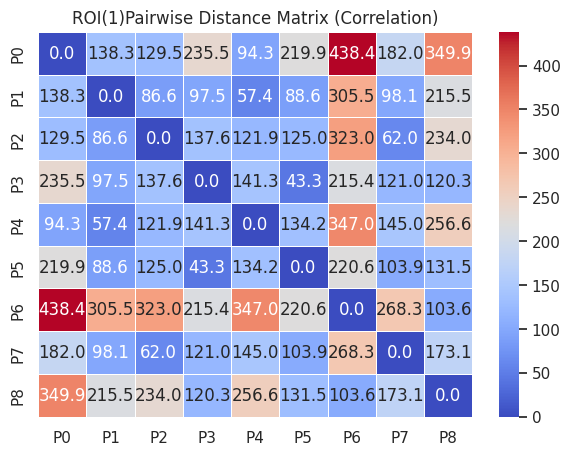

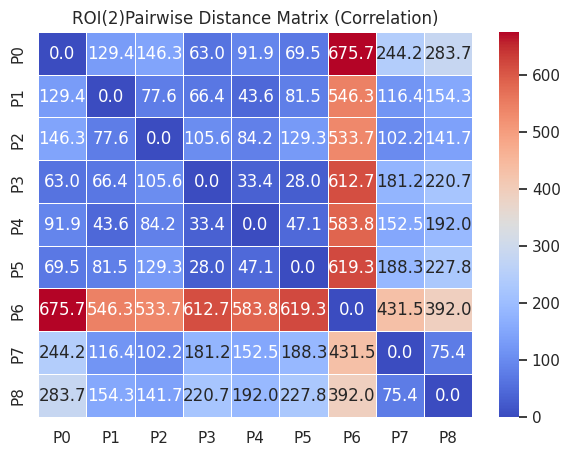

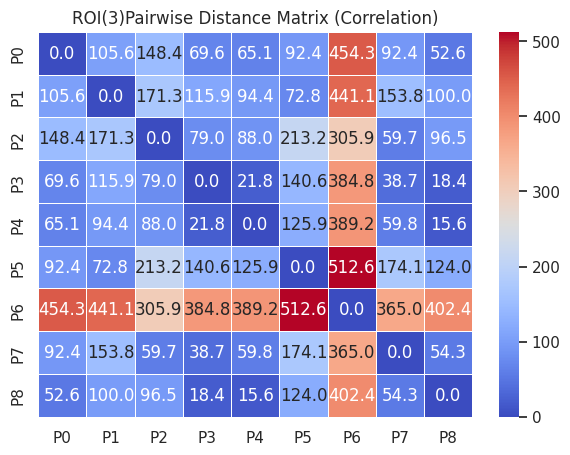

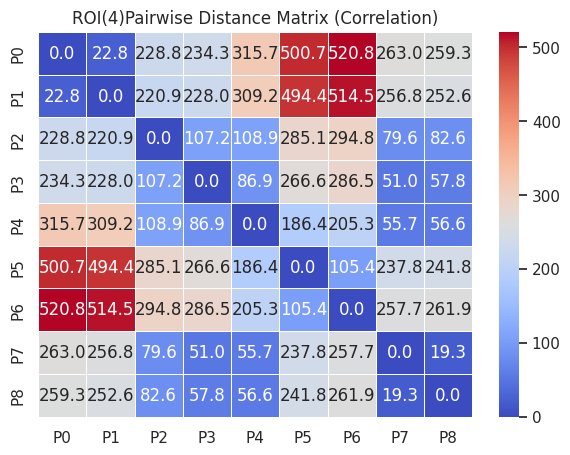

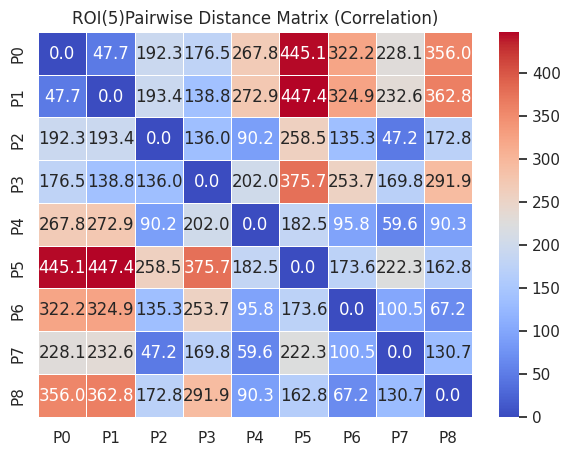

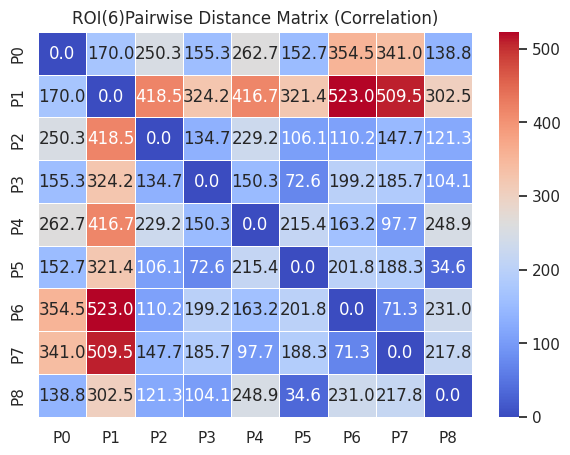

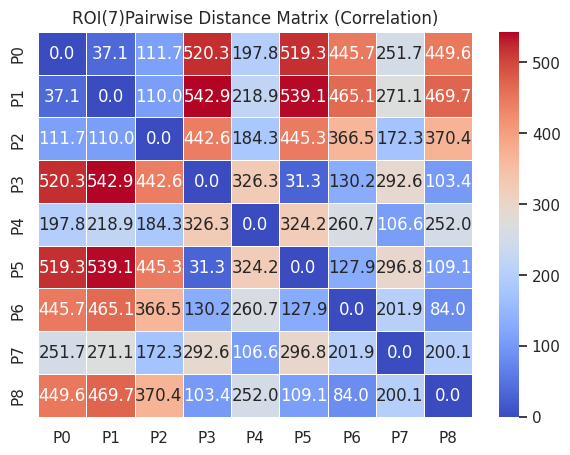

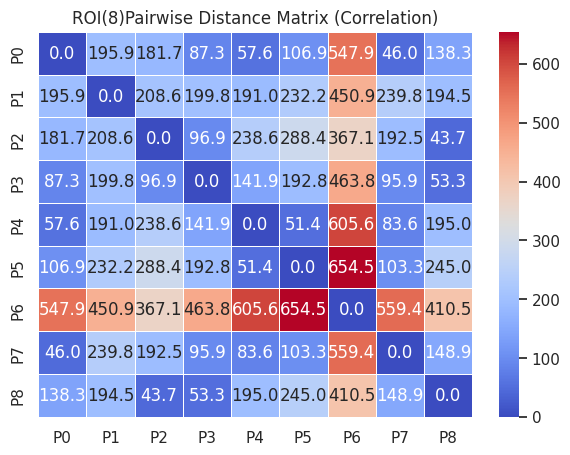

In [56]:
from scipy.stats import wasserstein_distance


# Define custom metric wrapper
def emd(u, v):
    return wasserstein_distance(u, v)

for j in range(num_rois):  # Spalten (ROIs)
    roi_indices_set = roi_indices[j]

    arrays = betas[:, roi_indices_set]

    

    distance_array = dist.pdist(arrays, metric=emd)
    dist_matrix = dist.squareform(distance_array)
    
    
    df_distance = pd.DataFrame(dist_matrix, columns=[f"P{i}" for i in range(len(betas))], index=[f"P{i}" for i in range(len(betas))])


    # Plot using seaborn heatmap
    plt.figure(figsize=(7, 5))
    sns.heatmap(df_distance, annot=True, cmap="coolwarm", fmt=".1f", linewidths=0.5)
    plt.title(f"ROI({j+1})Pairwise Distance Matrix (Correlation)")
    plt.show()

    

In [18]:
import numpy as np
import pandas as pd

res = np.zeros(t_rois.shape)
print(res.shape)
for roi in range(1, 8+1):
    roi_path = f"/media/Working/master_thesis/data/gaussian_results/subj_01/subj01/fitted_voxels_mask_{roi}.xlsx"
    data = pd.read_excel(roi_path)

    for i, row in data.iterrows():
        res[row["original_index"]] = row["var_train"]

    


(453622,)


In [28]:
len(res)

res_t = res[t_indices]
res_t

array([0.04890198, 0.06604856, 0.04680818, ..., 0.2362107 , 0.27419221,
       0.28969824])

/tmp/ipykernel_38583/3967466201.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


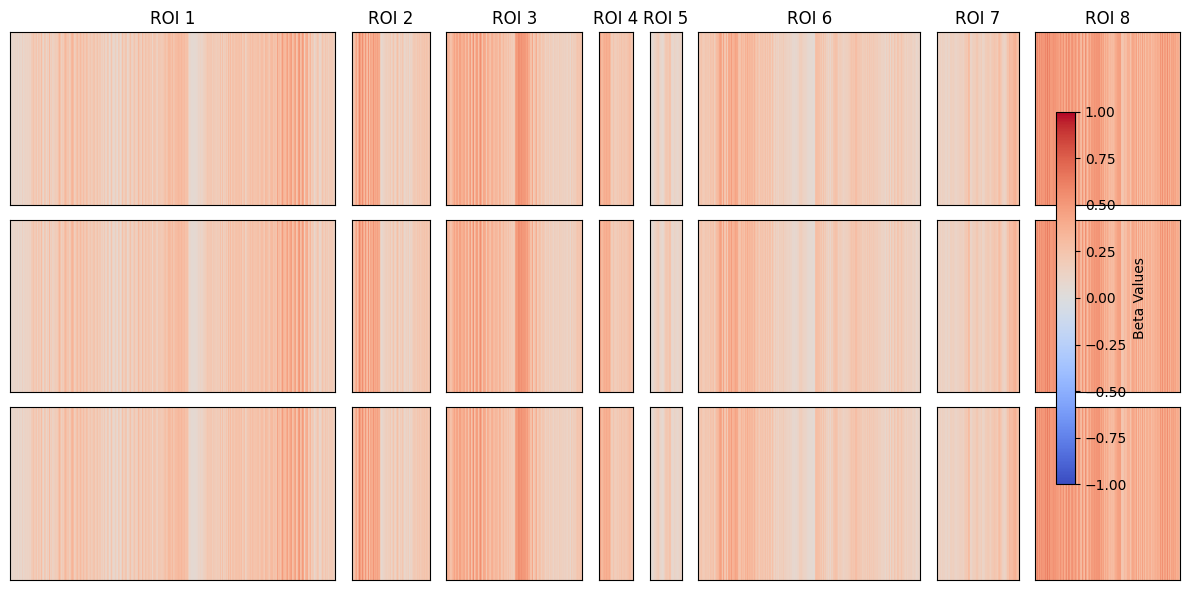

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# Beispielhafte Daten: 3 Arrays mit zufälliger Anzahl an Voxel pro ROI
num_rois = 8

# Berechne die relative Breite jeder Spalte basierend auf der Anzahl der Voxel
col_widths = [size / sum(roi_sizes) for size in roi_sizes]  # Normierte Breiten für `gridspec`

# Erstelle das Grid mit dynamischer Spaltenbreite
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(3, num_rois, width_ratios=col_widths)  # Flexible Breiten

# Erzeuge eine flache Liste von Subplots
axes = np.array([[fig.add_subplot(gs[i, j]) for j in range(num_rois)] for i in range(3)])

# Heatmaps zeichnen
for i in range(3):  # Zeilen (Arrays)
    for j in range(num_rois):  # Spalten (ROIs)
        roi_indices_set = roi_indices[j]


        var_roi = res_t[roi_indices_set]  # Beta-Werte nur für diesen ROI

        im = axes[i, j].imshow(var_roi.reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
        axes[i, j].set_xticks([])  # Keine X-Ticks
        axes[i, j].set_yticks([])  # Keine Y-Ticks

        # Spaltenbeschriftung in der obersten Zeile
        if i == 0:
            axes[i, j].set_title(f"ROI {j+1}")

# Farbskala hinzufügen (mit flacher Liste von Achsen)
cbar = fig.colorbar(im, ax=axes.ravel(), orientation="vertical", fraction=0.02, pad=0.05)
cbar.set_label("Beta Values")
plt.tight_layout()
plt.show()

4979
-2069


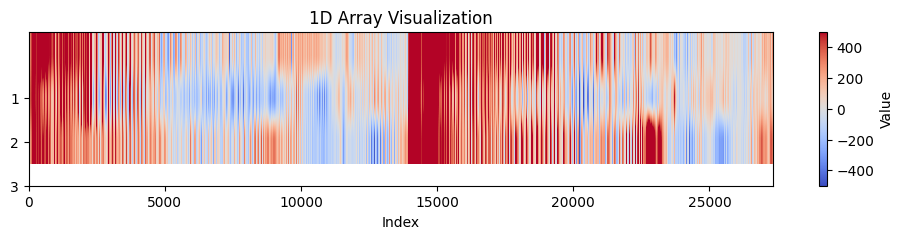

In [15]:

import matplotlib.pyplot as plt
import numpy as np

print(np.max(betas[0]))
print(np.min(betas[0]))


stacked = np.vstack(betas_results)

np.save("stacked_betas_random.npy", stacked)

plt.figure(figsize=(12, 2))  # Wide figure for better visualization
# plt.imshow(betas[0].reshape(1, -1), cmap="coolwarm", aspect="auto", vmax=500, vmin=-500)

plt.imshow(stacked, cmap="coolwarm", aspect="auto", vmax=500, vmin=-500)
plt.colorbar(label="Value")
plt.xlabel("Index")
plt.yticks([1, 2, 3])  # Remove y-axis labels (since it's a single row)
plt.title("1D Array Visualization")
plt.show()


In [12]:
stacked.shape

(15, 27321)

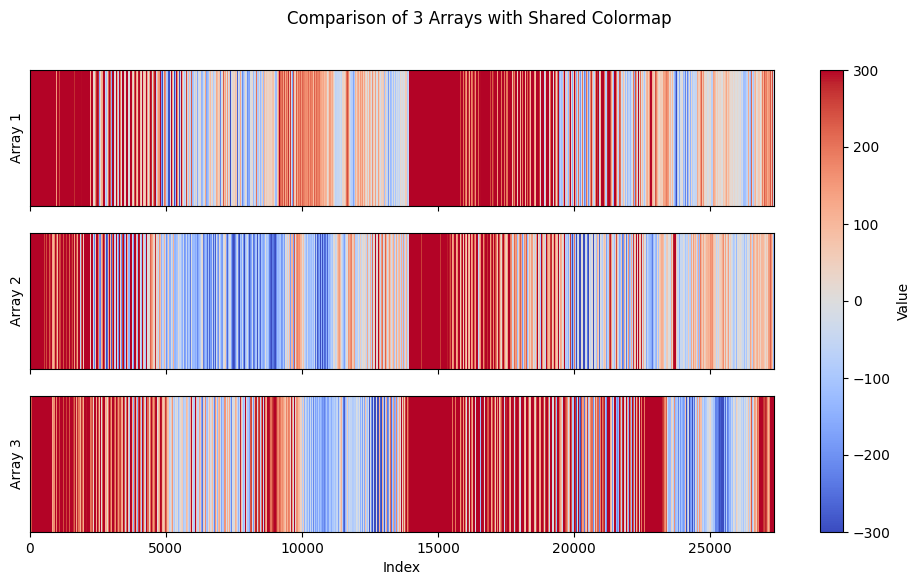

In [16]:

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True, sharey=True)



# Plot each array as a separate heatmap
for i, ax in enumerate(axes):
    im = ax.imshow(stacked[i].reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-300, vmax=300)
    ax.set_yticks([])  # Remove y-ticks
    ax.set_ylabel(f"Array {i+1}")  # Label each row

# Colorbar (one for all plots)
fig.colorbar(im, ax=axes, orientation="vertical", label="Value")

plt.xlabel("Index")
plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
plt.show()

(3, 453622)


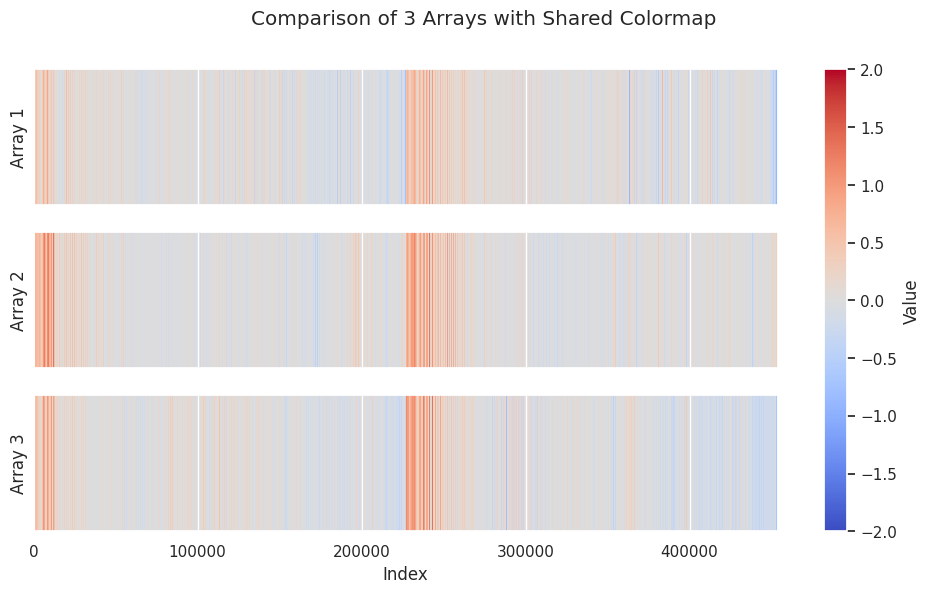

In [87]:
from sklearn.preprocessing import MinMaxScaler

rescaled = stacked.copy()
print(rescaled.shape)

def standardize(arr):
    mean = np.mean(arr)
    std = np.std(arr)

    z_scores = (arr - mean) / std

    return z_scores

for i in range(rescaled.shape[0]):
    rescaled[i] = standardize(rescaled[i])

fig, axes = plt.subplots(len(rescaled), 1, figsize=(12, 6), sharex=True, sharey=True)



# Plot each array as a separate heatmap
for i, ax in enumerate(axes):
    im = ax.imshow(rescaled[i].reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-2, vmax=2)
    ax.set_yticks([])  # Remove y-ticks
    ax.set_ylabel(f"Array {i+1}")  # Label each row

# Colorbar (one for all plots)
fig.colorbar(im, ax=axes, orientation="vertical", label="Value")

plt.xlabel("Index")
plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
plt.show()

[[1.         0.21441307 0.27797198]
 [0.21441307 1.         0.252412  ]
 [0.27797198 0.252412   1.        ]]


Text(0.5, 1.0, 'Correlation Heatmap for 18171')

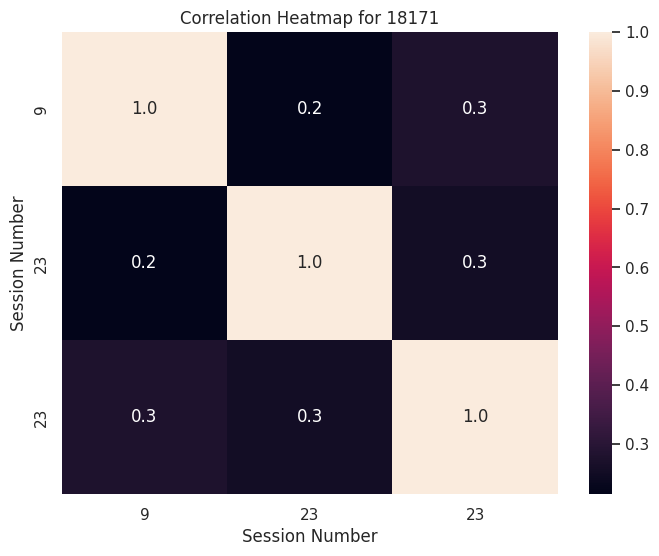

In [88]:
corrs = np.zeros((len(betas), len(betas)))
for i in range(len(betas)):
    for j in range(len(betas)):
        corr = scipy.stats.pearsonr(stacked[i], stacked[j])
        corrs[i, j] = corr.statistic


print(corrs)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    corrs, 
    annot=True, 
    fmt=".1f", 
    cbar=True, 
    xticklabels=session_numbers,  # Set x-axis labels
    yticklabels=session_numbers   # Set y-axis labels

)
plt.xlabel("Session Number")
plt.ylabel("Session Number")
plt.title(f"Correlation Heatmap for {id_loop}")




0.21519631912997617
PearsonRResult(statistic=np.float64(0.2113630791550874), pvalue=np.float64(0.0))
mse=np.float64(0.5850221324774261)
mse=np.float64(0.9583221272336879)


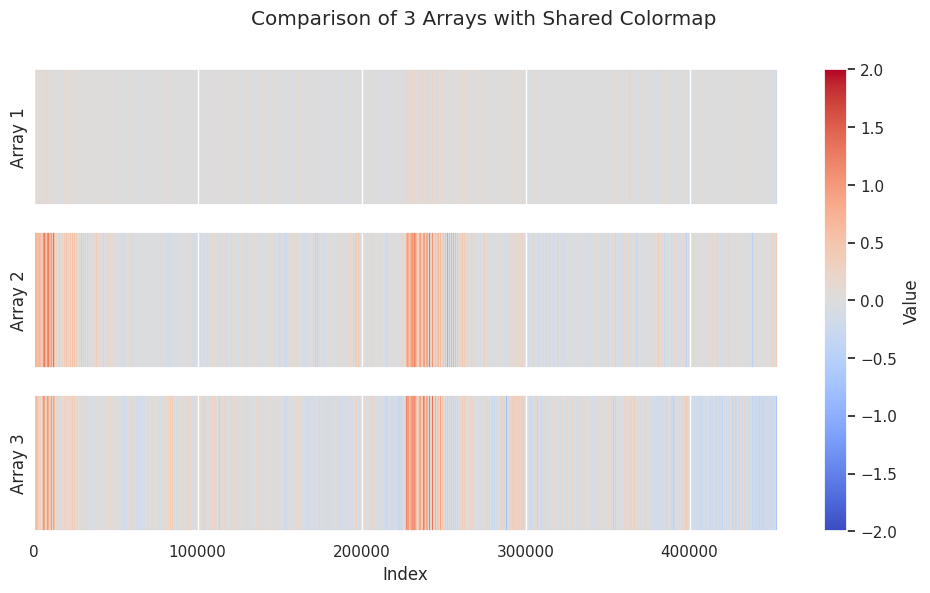

In [89]:
def optimal_scaling_factor(sample1, sample2):
    return np.sum(sample1 * sample2) / np.sum(sample1 ** 2)



f_opt = optimal_scaling_factor(rescaled[0], rescaled[1])
print(f_opt)

corr = scipy.stats.pearsonr(f_opt*rescaled[0], rescaled[1])
print(corr)

scaled_sample1 = f_opt * rescaled[0]
mse = np.mean((scaled_sample1 - rescaled[1]) ** 2)

print(f"{mse=}")
mse = np.mean((rescaled[0] - rescaled[1]) ** 2)
print(f"{mse=}")



fig, axes = plt.subplots(len(rescaled), 1, figsize=(12, 6), sharex=True, sharey=True)



# Plot each array as a separate heatmap
for i, ax in enumerate(axes):
    if i == 0:
        im = ax.imshow((f_opt*rescaled[i]).reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-2, vmax=2)
    else:
        im = ax.imshow(rescaled[i].reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-2, vmax=2)
    ax.set_yticks([])  # Remove y-ticks
    ax.set_ylabel(f"Array {i+1}")  # Label each row

# Colorbar (one for all plots)
fig.colorbar(im, ax=axes, orientation="vertical", label="Value")

plt.xlabel("Index")
plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
plt.show()